In [9]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, Any, List

In [10]:
def delta_vega_hedge(target_data: pd.DataFrame,
                     rep_data: pd.DataFrame,
                     hedge_frequency: int = 1) -> Dict[str, Any]:
    """
    data: DataFrame
        Contains data for a single option series
    """
    target_data = target_data.sort_values(by='date').reset_index(drop=True).copy()
    rep_data = rep_data.sort_values('date').copy()

    # align rep_date on target date gird
    rep_data = rep_data[['date', 'C', 'delta', 'vega']].copy()
    rep_data = rep_data.set_index('date')
    rep_data = rep_data.reindex(target_data['date'])

    if rep_data[['C', 'delta', 'vega']].isna().any().any():
        return None
    
    rep_data = rep_data.reset_index().rename(columns={'index': 'date'})

    N = len(target_data)

    delta_target = target_data.loc[0, 'delta']
    delta_rep = rep_data.loc[0, 'delta']
    vega_target = target_data.loc[0, 'vega']
    vega_rep = rep_data.loc[0, 'vega']
    
    C0 = target_data.loc[0, 'C']
    if vega_rep == 0:
        return None

    amount_S = delta_target - (vega_target / vega_rep) * delta_rep
    amount_rep = vega_target / vega_rep 

    errors = []

    for i in range(1, N):
        C1_target = target_data.loc[i - 1, 'C']
        C2_target = target_data.loc[i, 'C']
        S1_target = target_data.loc[i - 1, 'S']
        S2_target = target_data.loc[i, 'S']

        C1_rep = rep_data.loc[i - 1, 'C']
        C2_rep = rep_data.loc[i, 'C']

        A = (C2_target - C1_target) - (amount_S * (S2_target - S1_target) + amount_rep * (C2_rep - C1_rep))

        errors.append([target_data.loc[i, 'TTM'], A])

        if i % hedge_frequency == 0:
            delta_target = target_data.loc[i, 'delta']
            delta_rep = rep_data.loc[i, 'delta']
            vega_target = target_data.loc[i, 'vega']
            vega_rep = rep_data.loc[i, 'vega']

            if vega_rep == 0:
                return None
            
            amount_S = delta_target - (vega_target / vega_rep) * delta_rep
            amount_rep = vega_target / vega_rep

    error_df = pd.DataFrame(errors, columns=['TTM', 'error']) 
    result = {
        'expiration_date' : target_data['expiration_date'].iloc[0],
        'K' : target_data['K'].iloc[0],
        'initial_moneyness' : target_data['initial_moneyness'].iloc[0],
        'hedge_frequency' : hedge_frequency,
        'errors' : error_df,
        'mse' : np.mean((error_df['error']/C0)**2),
        'mean_error' : np.mean(error_df['error']),
        'std_error' : np.std(error_df['error'])
    }
    return result


In [11]:
def run_delta_vega_hedge_analysis(data: pd.DataFrame,
                                  pairs: pd.DataFrame,
                                  frequencies: List[int]) -> pd.DataFrame:
    # ensure expiration_date is datetime
    data2 = data.copy()
    data2['expiration_date'] = pd.to_datetime(data2['expiration_date'])
    data2['date'] = pd.to_datetime(data2['date'])

    # build mapping: target option_id -> hedge_option_id
    pair_map: Dict[str, str] = (
        pairs.drop_duplicates(subset=['option_id'])
             .set_index('option_id')['hedge_option_id']
             .to_dict()
    )

    results: List[Dict[str, Any]] = []

    # loop over moneyness buckets
    for mon in ['ATM', 'ITM', 'OTM']:
        data_mon = data2[data2['initial_moneyness'] == mon].copy()

        # group by target option_id
        for option_id, opt_data in data_mon.groupby('option_id'):

            # check if this option has a hedge partner
            if option_id not in pair_map:
                # no longer-maturity same-strike option
                continue

            hedge_id = pair_map[option_id]
            rep_data = data2[data2['option_id'] == hedge_id].copy()
            if rep_data.empty:
                continue

            # restrict target to last 45 *calendar* days before its maturity
            # (if you already did this earlier, this is just a safeguard)
            exp_date = opt_data['expiration_date'].iloc[0]
            mask_45 = (exp_date - opt_data['date']).dt.days.between(0, 45)
            target_45 = opt_data[mask_45].copy().sort_values('date')

            # need at least 2 observations to compute P&L
            if len(target_45) < 2:
                continue

            for freq in frequencies:
                res = delta_vega_hedge(
                    target_data=target_45,
                    rep_data=rep_data,
                    hedge_frequency=freq
                )
                if res is not None:
                    results.append(res)
                else:
                    # e.g. missing alignment or zero vega
                    # print(f"Skipping option_id {option_id} at freq={freq}.")
                    pass

    summary = pd.DataFrame(results)
    return summary

In [12]:
# import pandas as pd
# import numpy as np
# from typing import Dict, Any, Optional, List

# def _align_series_asof(target: pd.DataFrame,
#                        rep: pd.DataFrame,
#                        on: str = 'date',
#                        tolerance: pd.Timedelta = pd.Timedelta('1D'),
#                        direction: str = 'backward',
#                        interpolate: bool = False) -> Optional[pd.DataFrame]:
#     """
#     Align rep to target using merge_asof so every target date has a corresponding rep row
#     (previous tick by default). If interpolate=True we attempt to reindex rep to target dates
#     and linearly interpolate numeric columns.
#     Returns aligned rep DataFrame (same length, same date index) or None if too many misses.
#     """
#     target_sorted = target.sort_values(on).reset_index(drop=True)
#     rep_sorted = rep.sort_values(on).reset_index(drop=True)

#     # try merge_asof first (previous tick)
#     try:
#         aligned = pd.merge_asof(target_sorted[[on]],
#                                 rep_sorted,
#                                 on=on,
#                                 direction=direction,
#                                 tolerance=tolerance)
#     except Exception:
#         aligned = None

#     # if too many NaNs and interpolate requested, try interpolation
#     if aligned is None or aligned[['C','delta','vega']].isna().any(axis=None):
#         if not interpolate:
#             return None
#         # reindex and interpolate numeric columns
#         rep_reindexed = rep_sorted.set_index(on).reindex(target_sorted[on])
#         # attempt numeric interpolation (linear)
#         rep_reindexed[['C','delta','vega']] = rep_reindexed[['C','delta','vega']].interpolate(method='time', limit_direction='both')
#         rep_reindexed = rep_reindexed.reset_index().rename(columns={'index': on})
#         if rep_reindexed[['C','delta','vega']].isna().any(axis=None):
#             return None
#         aligned = rep_reindexed

#     return aligned.reset_index(drop=True)

# def delta_vega_hedge(target_data: pd.DataFrame,
#                      rep_data: pd.DataFrame,
#                      hedge_frequency: int = 1,
#                      vega_tol: float = 1e-8,
#                      align_tolerance: pd.Timedelta = pd.Timedelta('1D'),
#                      interpolate_rep: bool = True,
#                      contract_multiplier_target: float = 1.0,
#                      contract_multiplier_rep: float = 1.0,
#                      include_notional: bool = True
#                     ) -> Optional[Dict[str, Any]]:
#     """
#     More robust delta-vega hedging calculation.
#     - Aligns rep_data to target_data using merge_asof / interpolation.
#     - Uses a vega tolerance to avoid extreme ratios.
#     - contract_multiplier_*: scale if contract sizes differ (e.g. 100 shares per option).
#     Returns dict with same structure as before or None if alignment fails / zero vega.
#     """

#     # prepare copies and datetimes
#     target = target_data.sort_values('date').reset_index(drop=True).copy()
#     rep = rep_data.sort_values('date').reset_index(drop=True).copy()

#     # ensure datetime
#     target['date'] = pd.to_datetime(target['date'])
#     rep['date'] = pd.to_datetime(rep['date'])

#     # align rep onto target grid
#     aligned_rep = _align_series_asof(target, rep,
#                                      on='date',
#                                      tolerance=align_tolerance,
#                                      direction='backward',
#                                      interpolate=interpolate_rep)
#     if aligned_rep is None:
#         return None

#     # pick initial greeks (index 0)
#     delta_target = float(target.loc[0, 'delta'])
#     delta_rep = float(aligned_rep.loc[0, 'delta'])
#     vega_target = float(target.loc[0, 'vega'])
#     vega_rep = float(aligned_rep.loc[0, 'vega'])

#     C0 = float(target.loc[0, 'C'])
#     # adjust for contract multipliers (put greeks on same notional basis)
#     vega_rep_adj = vega_rep * (contract_multiplier_rep / contract_multiplier_target)
#     delta_rep_adj = delta_rep * (contract_multiplier_rep / contract_multiplier_target)

#     if abs(vega_rep_adj) < vega_tol:
#         # cannot hedge vega with near-zero vega_rep
#         return None

#     # hedge amounts (number of underlying shares and number of rep option contracts)
#     # amount_rep: how many rep options (in target-option-contract units) to neutralize vega
#     amount_rep = vega_target / vega_rep_adj
#     # amount_S: shares needed to get delta neutral after adding rep option exposure
#     amount_S = delta_target - amount_rep * delta_rep_adj

#     errors = []
#     traded_notional = {'shares': 0.0, 'rep_options': 0.0}

#     N = len(target)
#     for i in range(1, N):
#         # target deltas in underlying P&L
#         C1_target = float(target.loc[i - 1, 'C'])
#         C2_target = float(target.loc[i, 'C'])
#         S1 = float(target.loc[i - 1, 'S'])
#         S2 = float(target.loc[i, 'S'])

#         # rep option P&L (aligned)
#         C1_rep = float(aligned_rep.loc[i - 1, 'C'])
#         C2_rep = float(aligned_rep.loc[i, 'C'])

#         pnl_hedge = amount_S * (S2 - S1) + amount_rep * (C2_rep - C1_rep)
#         A = (C2_target - C1_target) - pnl_hedge

#         errors.append([target.loc[i, 'TTM'], A])

#         # accumulate notional (approx)
#         if include_notional:
#             traded_notional['shares'] += abs(amount_S) * abs(S2 - S1)
#             traded_notional['rep_options'] += abs(amount_rep) * abs(C2_rep - C1_rep)

#         # update hedge every hedge_frequency steps
#         if i % hedge_frequency == 0:
#             delta_target = float(target.loc[i, 'delta'])
#             delta_rep = float(aligned_rep.loc[i, 'delta'])
#             vega_target = float(target.loc[i, 'vega'])
#             vega_rep = float(aligned_rep.loc[i, 'vega'])

#             # re-adjust for contract multipliers
#             vega_rep_adj = vega_rep * (contract_multiplier_rep / contract_multiplier_target)
#             delta_rep_adj = delta_rep * (contract_multiplier_rep / contract_multiplier_target)

#             if abs(vega_rep_adj) < vega_tol:
#                 return None

#             amount_rep = vega_target / vega_rep_adj
#             amount_S = delta_target - amount_rep * delta_rep_adj

#     error_df = pd.DataFrame(errors, columns=['TTM', 'error'])
#     result = {
#         'expiration_date' : target['expiration_date'].iloc[0],
#         'K' : target['K'].iloc[0],
#         'initial_moneyness' : target['initial_moneyness'].iloc[0],
#         'hedge_frequency' : hedge_frequency,
#         'errors' : error_df,
#         'mse' : float(np.mean((error_df['error']/C0)**2)) if len(error_df) else np.nan,
#         'mean_error' : float(np.mean(error_df['error'])) if len(error_df) else np.nan,
#         'std_error' : float(np.std(error_df['error'])) if len(error_df) else np.nan,
#         'amount_S_initial' : float(amount_S),
#         'amount_rep_initial' : float(amount_rep),
#         'traded_notional_approx' : traded_notional
#     }
#     return result

# # small change to the run loop: use days_to_exp explicit calculation and keep counters for skipped
# def run_delta_vega_hedge_analysis(data: pd.DataFrame,
#                                   pairs: pd.DataFrame,
#                                   frequencies: List[int],
#                                   align_tolerance_days: int = 1,
#                                   interpolate_rep: bool = True) -> pd.DataFrame:
#     data = data.copy()
#     data['expiration_date'] = pd.to_datetime(data['expiration_date'])
#     data['date'] = pd.to_datetime(data['date'])

#     pair_map = pairs.drop_duplicates(subset=['option_id']).set_index('option_id')['hedge_option_id'].to_dict()

#     results = []
#     skip_counts = {'no_pair':0, 'rep_missing':0, 'too_few_obs':0, 'align_fail_or_zero_vega':0}

#     for mon in ['ATM','ITM','OTM']:
#         data_mon = data[data['initial_moneyness'] == mon].copy()
#         for option_id, opt_data in data_mon.groupby('option_id'):
#             if option_id not in pair_map:
#                 skip_counts['no_pair'] += 1
#                 continue
#             hedge_id = pair_map[option_id]
#             rep_data = data[data['option_id'] == hedge_id].copy()
#             if rep_data.empty:
#                 skip_counts['rep_missing'] += 1
#                 continue

#             # only last 45 calendar days before maturity
#             days_to_exp = (opt_data['expiration_date'] - opt_data['date']).dt.days
#             mask = days_to_exp.between(0,45)
#             target_45 = opt_data[mask].copy().sort_values('date')
#             if len(target_45) < 2:
#                 skip_counts['too_few_obs'] += 1
#                 continue

#             for freq in frequencies:
#                 res = delta_vega_hedge(
#                     target_data=target_45,
#                     rep_data=rep_data,
#                     hedge_frequency=freq,
#                     align_tolerance=pd.Timedelta(f"{align_tolerance_days}D"),
#                     interpolate_rep=interpolate_rep
#                 )
#                 if res is None:
#                     skip_counts['align_fail_or_zero_vega'] += 1
#                 else:
#                     results.append(res)

#     summary = pd.DataFrame(results)
#     # attach skip counts for debugging (optional)
#     summary.attrs['skip_counts'] = skip_counts
#     return summary


In [13]:
ticker = 'AAPL'
data = pd.read_csv(f"AAPL_processed_vega.csv")

# stop_id = "AAPL_2021-03-19_K175"
# idx = df.index[df["option_id"] == stop_id][0]
# dataraw = df.loc[:idx]


# data = dataraw.copy()

# # Define conditions and choices
# conditions = [
#     data['delta_start'] < 0.35,
#     data['delta_start'] > 0.65,
#     (data['delta_start'] >= 0.45) & (data['delta_start'] <= 0.55)
# ]

# choices = ['OTM', 'ITM', 'ATM']

# # Apply conditions
# data['initial_moneyness'] = np.select(conditions, choices, default=data['initial_moneyness'])


data['date'] = pd.to_datetime(data['date'])
data['expiration_date'] = pd.to_datetime(data['expiration_date'])

In [14]:
per_option = (
    data[['option_id', 'K', 'expiration_date']]
    .drop_duplicates()
)

expiries = sorted(per_option['expiration_date'].unique())
next_expiry_map = {}
for i in range(len(expiries) - 1):
    next_expiry_map[expiries[i]] = expiries[i+1]

per_option['next_expiration'] = per_option['expiration_date'].map(next_expiry_map)  #add to per option the next expiration date 

In [15]:
#create option pairs

# Left: options at T1
left = per_option.dropna(subset=['next_expiration']).copy()

# Right: potential hedge options at T2
right = per_option.rename(
    columns={
        'option_id': 'hedge_option_id',
        'expiration_date': 'hedge_expiration'
    }
)

# Merge on strike + matching T2
pairs = left.merge(
    right,
    left_on=['K', 'next_expiration'],
    right_on=['K', 'hedge_expiration'],
    how='inner'
)

# pairs now has: option_id (T1) and hedge_option_id (T2) with same K
print(pairs[['option_id', 'expiration_date', 'K',
             'hedge_option_id', 'hedge_expiration']].head())
print("Number of hedgeable options:", pairs['option_id'].nunique())


              option_id expiration_date      K       hedge_option_id  \
0  AAPL_2020-09-18_K115      2020-09-18  115.0  AAPL_2020-10-16_K115   
1  AAPL_2020-09-18_K120      2020-09-18  120.0  AAPL_2020-10-16_K120   
2  AAPL_2020-09-18_K125      2020-09-18  125.0  AAPL_2020-10-16_K125   
3  AAPL_2020-10-16_K115      2020-10-16  115.0  AAPL_2020-11-20_K115   
4  AAPL_2020-10-16_K120      2020-10-16  120.0  AAPL_2020-11-20_K120   

  hedge_expiration  
0       2020-10-16  
1       2020-10-16  
2       2020-10-16  
3       2020-11-20  
4       2020-11-20  
Number of hedgeable options: 145


In [16]:
moneness_info = (
    data[['option_id', 'initial_moneyness']]
    .drop_duplicates()
)

# merge onto pairs
pairs = pairs.merge(moneness_info, on='option_id', how='left')

# count how many *hedgeable* options per moneyness
hedgeable_counts = (
    pairs.groupby('initial_moneyness')['option_id']
         .nunique()
         .sort_index()
)

print("Hedgeable options per moneyness:")
print(hedgeable_counts)

Hedgeable options per moneyness:
initial_moneyness
ATM      8
ITM     11
OTM    126
Name: option_id, dtype: int64


## AAAAAAA

In [17]:
per_option = (
    data[['option_id', 'K', 'expiration_date']]
    .drop_duplicates()
    .copy()
)

# make sure expiration_date is datetime
per_option['expiration_date'] = pd.to_datetime(per_option['expiration_date'])

expiries = sorted(per_option['expiration_date'].unique())

# map T1 → T2
next_expiry_map = {
    expiries[i]: expiries[i+1]
    for i in range(len(expiries) - 1)
}

per_option['next_expiration'] = per_option['expiration_date'].map(next_expiry_map)

# Left = target option (shorter maturity)
left = per_option.dropna(subset=['next_expiration']).copy()

# Right = hedge option (longer maturity), rename for clarity
right = per_option.rename(columns={
    'option_id': 'hedge_option_id',
    'expiration_date': 'hedge_expiration'
})

pairs = left.merge(
    right,
    left_on=['K', 'next_expiration'],
    right_on=['K', 'hedge_expiration'],
    how='inner'
)

# to see how many hedgeable options exist per moneyness
moneness_info = (
    data[['option_id', 'initial_moneyness']]
    .drop_duplicates()
)

pairs = pairs.merge(moneness_info, on='option_id', how='left')

print(pairs['initial_moneyness'].value_counts())


initial_moneyness
OTM    126
ITM     11
ATM      8
Name: count, dtype: int64


In [18]:
pairs.head()

,option_id,K,expiration_date,next_expiration_x,hedge_option_id,hedge_expiration,next_expiration_y,initial_moneyness
0,AAPL_2020-09-18_K115,115.0,2020-09-18,2020-10-16,AAPL_2020-10-16_K115,2020-10-16,2020-11-20,OTM
1,AAPL_2020-09-18_K120,120.0,2020-09-18,2020-10-16,AAPL_2020-10-16_K120,2020-10-16,2020-11-20,OTM
2,AAPL_2020-09-18_K125,125.0,2020-09-18,2020-10-16,AAPL_2020-10-16_K125,2020-10-16,2020-11-20,OTM
3,AAPL_2020-10-16_K115,115.0,2020-10-16,2020-11-20,AAPL_2020-11-20_K115,2020-11-20,2020-12-18,OTM
4,AAPL_2020-10-16_K120,120.0,2020-10-16,2020-11-20,AAPL_2020-11-20_K120,2020-11-20,2020-12-18,OTM


In [19]:
frequencies = [1, 2, 3, 7]
moneyness_levels = ['ITM', 'ATM', 'OTM']
delta_vega_summary = run_delta_vega_hedge_analysis(
    data=data,   #historical value
    pairs=pairs, #replicating
    frequencies=frequencies
)


In [20]:
aggregated_deltavega_summary = (
    delta_vega_summary
    .groupby(['hedge_frequency', 'initial_moneyness'])['mse']
    .agg(
        mean_mse='mean',
        std_mse='std',
        n_options='count'
    )
    .reset_index()
)

aggregated_deltavega_summary['initial_moneyness'] = pd.Categorical(
    aggregated_deltavega_summary['initial_moneyness'],
    categories=moneyness_levels,
    ordered=True
)

aggregated_deltavega_summary = aggregated_deltavega_summary.sort_values([
    'hedge_frequency',
    'initial_moneyness'
])
print(aggregated_deltavega_summary)

    hedge_frequency initial_moneyness  mean_mse   std_mse  n_options
1                 1               ITM  0.000903  0.000780         10
0                 1               ATM  0.002409  0.004021          8
2                 1               OTM  0.068493  0.291541        122
4                 2               ITM  0.001589  0.001923         10
3                 2               ATM  0.002828  0.004741          8
5                 2               OTM  0.092455  0.378549        122
7                 3               ITM  0.002511  0.003940         10
6                 3               ATM  0.003931  0.007282          8
8                 3               OTM  0.116381  0.518880        122
10                7               ITM  0.002525  0.002660         10
9                 7               ATM  0.004232  0.005396          8
11                7               OTM  0.138054  0.530368        122


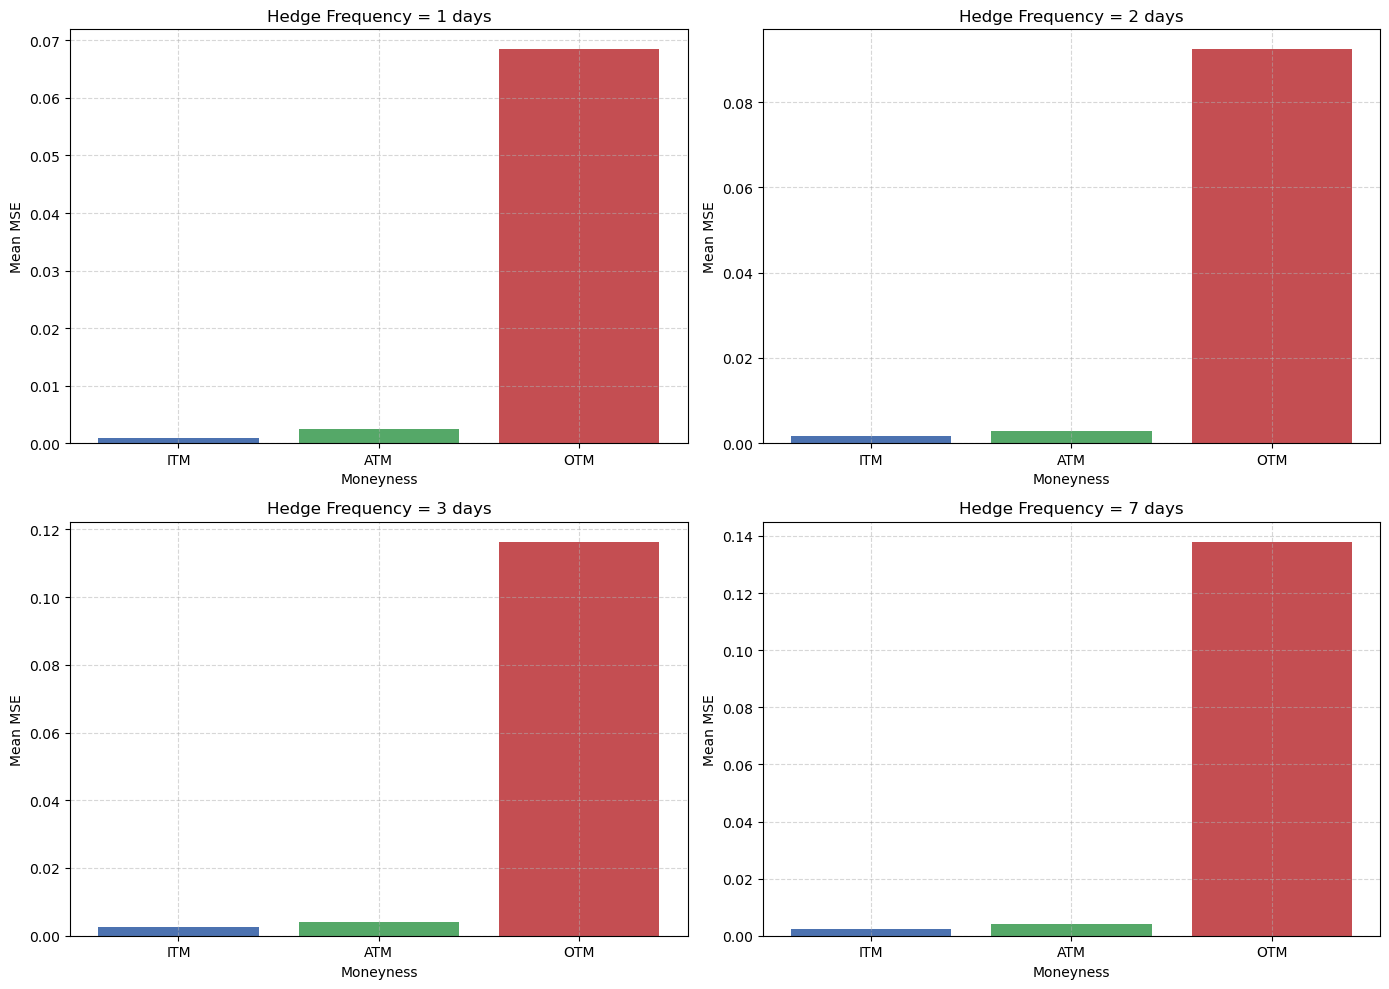

In [21]:
# Use this depending on your summary source:
df = aggregated_deltavega_summary   # or delta_summary

# Define order
frequencies = [1, 2, 3, 7]
moneyness_levels = ["ITM", "ATM", "OTM"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, freq in enumerate(frequencies):
    ax = axes[idx]

    # Filter data for this frequency
    d = df[df['hedge_frequency'] == freq]

    # Compute mean MSE per moneyness
    means = (
        d.groupby("initial_moneyness", observed=True)['mean_mse']
        .mean()
        .reindex(moneyness_levels)
    )

    # Plot bar chart
    ax.bar(moneyness_levels, means.values, color=["#4C72B0", "#55A868", "#C44E52"])

    ax.set_title(f"Hedge Frequency = {freq} days")
    ax.set_xlabel("Moneyness")
    ax.set_ylabel("Mean MSE")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [22]:
aggregated_freq = (
    delta_vega_summary
    .groupby('hedge_frequency')['mse']
    .agg(
        mean_mse="mean",
        std_mse="std",
        n_options="count"
    )
    .reset_index()
    .sort_values("hedge_frequency")
)
aggregated_freq

,hedge_frequency,mean_mse,std_mse,n_options
0,1,0.059889,0.272939,140
1,2,0.080843,0.354492,140
2,3,0.101822,0.485615,140
3,7,0.120726,0.496906,140


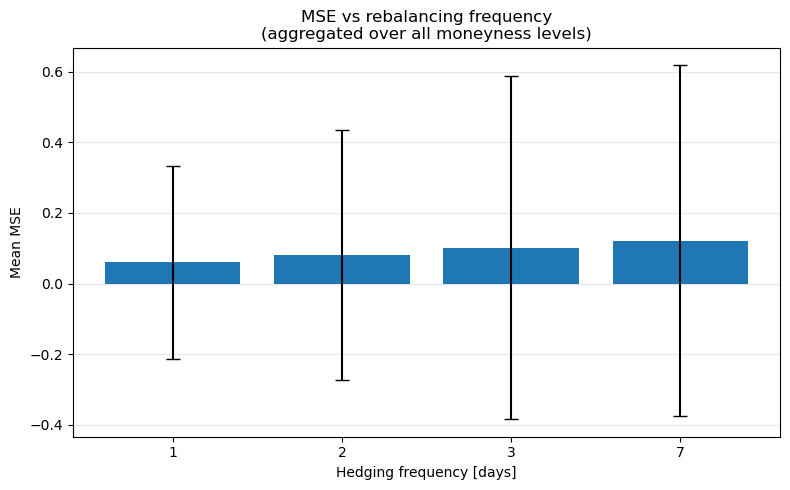

In [23]:
plt.figure(figsize=(8, 5))

x = np.arange(len(aggregated_freq))
means = aggregated_freq["mean_mse"].values
stds = aggregated_freq["std_mse"].values
labels = aggregated_freq["hedge_frequency"].astype(str).tolist()

plt.bar(x, means, yerr=stds, capsize=5)
plt.xticks(x, labels)

plt.xlabel("Hedging frequency [days]")
plt.ylabel("Mean MSE")
plt.title("MSE vs rebalancing frequency\n(aggregated over all moneyness levels)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

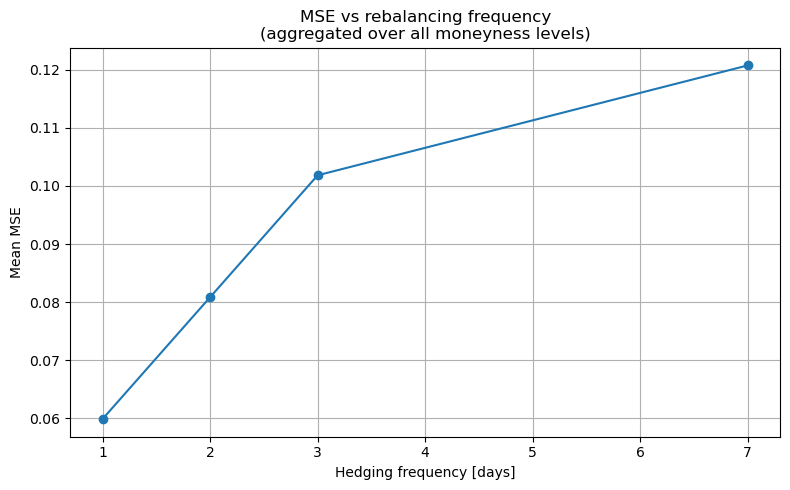

In [24]:
# for showing monotonicity
plt.figure(figsize=(8, 5))

plt.errorbar(
    aggregated_freq["hedge_frequency"],
    aggregated_freq["mean_mse"],
    fmt="o-",
    capsize=5
)

plt.xlabel("Hedging frequency [days]")
plt.ylabel("Mean MSE")
plt.title("MSE vs rebalancing frequency\n(aggregated over all moneyness levels)")
plt.grid(True)
plt.tight_layout()
plt.savefig("deltavega_mse.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
aggregated_deltavega_summary.head()

,hedge_frequency,initial_moneyness,mean_mse,std_mse,n_options
1,1,ITM,0.000903,0.000780,10
0,1,ATM,0.002409,0.004021,8
2,1,OTM,0.068493,0.291541,122
4,2,ITM,0.001589,0.001923,10
3,2,ATM,0.002828,0.004741,8


In [26]:
pivot_mse = aggregated_deltavega_summary.pivot(
    index='initial_moneyness',
    columns='hedge_frequency',
    values='mean_mse'
)

pivot_std = aggregated_deltavega_summary.pivot(
    index='initial_moneyness',
    columns='hedge_frequency',
    values='std_mse'
)
pivot_mse


hedge_frequency,1,2,3,7
initial_moneyness,,,,
ITM,0.000903,0.001589,0.002511,0.002525
ATM,0.002409,0.002828,0.003931,0.004232
OTM,0.068493,0.092455,0.116381,0.138054


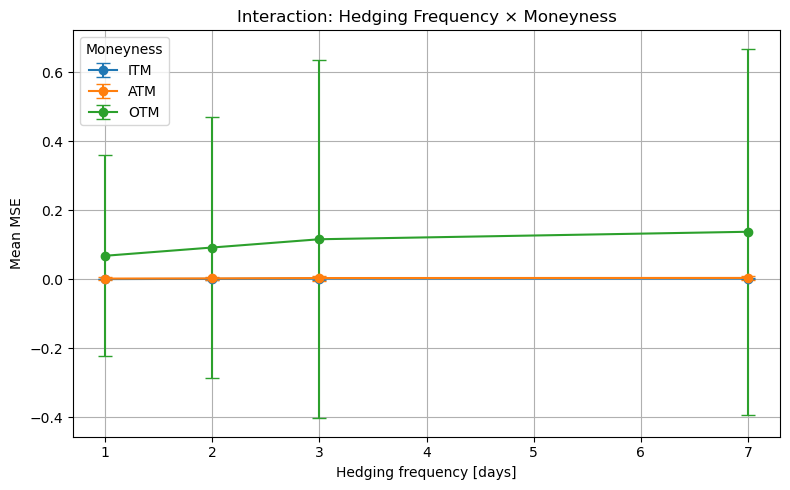

In [27]:
plt.figure(figsize=(8, 5))
for mon in moneyness_levels:
    df_mon = aggregated_deltavega_summary[aggregated_deltavega_summary["initial_moneyness"] == mon]
    plt.errorbar(
        df_mon["hedge_frequency"],
        df_mon["mean_mse"],
        yerr=df_mon["std_mse"],
        capsize=5,
        marker="o",
        label=mon
    )

plt.xlabel("Hedging frequency [days]")
plt.ylabel("Mean MSE")
plt.title("Interaction: Hedging Frequency × Moneyness")
plt.legend(title="Moneyness")
plt.grid(True)
plt.tight_layout()
plt.savefig("deltavega_moneyness.png", dpi=300, bbox_inches="tight")
plt.show()